In [50]:
#########################################
# Step 1. Imports
#########################################
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
import arch
from arch.univariate import ConstantMean, GARCH, Normal
import keras_tuner as kt
from imblearn.over_sampling import RandomOverSampler
import keras.backend as K
import sys
sys.path.append('../Drafts')
from processing_module import round_hours

In [100]:
#########################################
# Step 1. Load Data
#########################################
dot_prices  = pd.read_parquet('../Crypto_QTS_Data_Processed/dot_price_processed.parquet')
dot_staking = pd.read_parquet('../data/on_chain_data/processed/dot_staking_data.parquet')
dot_tech    = pd.read_parquet('../data/data_segmented_tech/dot_data.parquet')

#########################################
# Step 2. Convert Indices to DateTime
#########################################
dot_staking.index = pd.to_datetime(dot_staking.index)

dot_prices.index = pd.to_datetime(dot_prices.index)

dot_tech['time_close'] = pd.to_datetime(dot_tech['time_close'])
dot_tech['time_close'] = dot_tech['time_close'].dt.round('min')
dot_tech.set_index('time_close', inplace=True)

#########################################
# Step 3. Use Staking Data as On-Chain Features
#########################################
dot_features = dot_staking.copy()

#########################################
# Step 4. Clean and Align Price Data
#########################################
# Determine the global common time range across features, prices, and tech data
global_start = max(dot_features.index.min(), dot_prices.index.min(), dot_tech.index.min())
global_end   = min(dot_features.index.max(), dot_prices.index.max(), dot_tech.index.max())

dot_features_aligned = dot_features.loc[global_start:global_end]
dot_prices_aligned   = dot_prices.loc[global_start:global_end]

#########################################
# Step 5. Process and Align Technical Indicator Data
#########################################
# Subset tech data using the global common time range
dot_tech_aligned = dot_tech.loc[global_start:global_end].copy()

# Ensure both DataFrames have unique indices by dropping duplicates
dot_prices_aligned = dot_prices_aligned[~dot_prices_aligned.index.duplicated(keep='first')]
dot_tech_aligned   = dot_tech_aligned[~dot_tech_aligned.index.duplicated(keep='first')]

# Reindex the tech data to match the unique price data timestamps using nearest match
dot_tech_aligned = dot_tech_aligned.reindex(dot_prices_aligned.index, method='nearest')

tech_cols = ['fib_23', 'fib_38', 'fib_50', 'fib_61', 'fib_78', 'bollinger', 'EMAcross', 'RSI']
dot_tech_selected = dot_tech_aligned[tech_cols].rename(columns=lambda x: "tech_" + x)

#########################################
# Step 6. Join Price Data with Feature Data
#########################################
data = dot_features_aligned.join(
    dot_prices_aligned[['price_close']], 
    how='inner'
)

#########################################
# Step 7. Join Tech Features to Main Data
#########################################
data = data.join(dot_tech_selected, how='left')

#########################################
# Step 8. Unified Lag Adjustment for All Feature Columns
#########################################
lag_cols = [ 
    'real_reward_rate',
    'staked_tokens', 'staking_ratio','active_validators'
]
tech_cols_renamed = ["tech_" + col for col in tech_cols]
all_lag_cols = lag_cols + tech_cols_renamed

# Apply a lag of 1 to all feature columns (price_close remains unshifted)
print("Missing values per column:\n", data.isna().sum())
data[all_lag_cols] = data[all_lag_cols].shift(1)
print("Missing values per column:\n", data.isna().sum())


Missing values per column:
 active_validators    0
real_reward_rate     0
staked_tokens        0
staking_ratio        0
price_close          0
tech_fib_23          0
tech_fib_38          0
tech_fib_50          0
tech_fib_61          0
tech_fib_78          0
tech_bollinger       0
tech_EMAcross        0
tech_RSI             0
dtype: int64
Missing values per column:
 active_validators    1
real_reward_rate     1
staked_tokens        1
staking_ratio        1
price_close          0
tech_fib_23          1
tech_fib_38          1
tech_fib_50          1
tech_fib_61          1
tech_fib_78          1
tech_bollinger       1
tech_EMAcross        1
tech_RSI             1
dtype: int64


In [93]:
#########################################
# Step 1. Load Data
#########################################
near_prices  = pd.read_parquet('../Crypto_QTS_Data_Processed/near_price_processed.parquet')
near_staking = pd.read_parquet('../data/on_chain_data/processed/near_staking_data.parquet')
near_tech    = pd.read_parquet('../data/data_segmented_tech/near_data.parquet')

#########################################
# Step 2. Convert Indices to DateTime
#########################################
near_staking.index = pd.to_datetime(near_staking.index)

near_prices.index = pd.to_datetime(near_prices.index)

near_tech['time_close'] = pd.to_datetime(near_tech['time_close'])
near_tech['time_close'] = near_tech['time_close'].dt.round('min')
near_tech.set_index('time_close', inplace=True)

#########################################
# Step 3. Use Staking Data as On-Chain Features
#########################################
near_features = near_staking.copy()

#########################################
# Step 4. Clean and Align Price Data
#########################################
# Determine the global common time range across features, prices, and tech data
global_start = max(near_features.index.min(), near_prices.index.min(), near_tech.index.min())
global_end   = min(near_features.index.max(), near_prices.index.max(), near_tech.index.max())

near_features_aligned = near_features.loc[global_start:global_end]
near_prices_aligned   = near_prices.loc[global_start:global_end]

#########################################
# Step 5. Process and Align Technical Indicator Data
#########################################
# Subset tech data using the global common time range
near_tech_aligned = near_tech.loc[global_start:global_end].copy()

# Ensure both DataFrames have unique indices by dropping duplicates
near_prices_aligned = near_prices_aligned[~near_prices_aligned.index.duplicated(keep='first')]
near_tech_aligned   = near_tech_aligned[~near_tech_aligned.index.duplicated(keep='first')]

# Reindex the tech data to match the unique price data timestamps using nearest match
near_tech_aligned = near_tech_aligned.reindex(near_prices_aligned.index, method='nearest')

tech_cols = ['fib_23', 'fib_38', 'fib_50', 'fib_61', 'fib_78', 'bollinger', 'EMAcross', 'RSI']
near_tech_selected = near_tech_aligned[tech_cols].rename(columns=lambda x: "tech_" + x)

#########################################
# Step 6. Join Price Data with Feature Data
#########################################
data = near_features_aligned.join(
    near_prices_aligned[['price_close']], 
    how='inner'
)

#########################################
# Step 7. Join Tech Features to Main Data
#########################################
data = data.join(near_tech_selected, how='left')

#########################################
# Step 8. Unified Lag Adjustment for All Feature Columns
#########################################
lag_cols = [ 
    'real_reward_rate',
    'staked_tokens', 'staking_ratio',
]
tech_cols_renamed = ["tech_" + col for col in tech_cols]
all_lag_cols = lag_cols + tech_cols_renamed

# Apply a lag of 1 to all feature columns (price_close remains unshifted)
print("Missing values per column:\n", data.isna().sum())
data[all_lag_cols] = data[all_lag_cols].shift(1)
print("Missing values per column:\n", data.isna().sum())


Missing values per column:
 real_reward_rate    0
staked_tokens       0
staking_ratio       0
price_close         0
tech_fib_23         0
tech_fib_38         0
tech_fib_50         0
tech_fib_61         0
tech_fib_78         0
tech_bollinger      0
tech_EMAcross       0
tech_RSI            0
dtype: int64
Missing values per column:
 real_reward_rate    1
staked_tokens       1
staking_ratio       1
price_close         0
tech_fib_23         1
tech_fib_38         1
tech_fib_50         1
tech_fib_61         1
tech_fib_78         1
tech_bollinger      1
tech_EMAcross       1
tech_RSI            1
dtype: int64


In [66]:
sol_prices = pd.read_parquet('../data/price_data/processed/sol_processed_data.parquet')
sol_features = pd.read_parquet('../Crypto_QTS_Data_Processed/sol_chain_processed.parquet')#.drop(columns=['average_difficulty','average_base_fee_per_gas','average_difficulty'])
sol_staking = pd.read_parquet('../data/on_chain_data/processed/sol_staking_data.parquet')
sol_tech = pd.read_parquet('../data/data_segmented_tech/sol_data.parquet')

sol_staking.index   = pd.to_datetime(sol_staking.index)
sol_features.index = pd.to_datetime(sol_features.index)

sol_prices['time_close'] = pd.to_datetime(sol_prices['time_close'])
sol_prices['time_close'] = sol_prices['time_close'].dt.tz_localize('UTC')
sol_prices.set_index('time_close', inplace=True)
sol_prices.index = sol_prices.index + pd.Timedelta(minutes=1)

sol_tech['time_close'] = pd.to_datetime(sol_tech['time_close'])
sol_tech['time_close'] = sol_tech['time_close'].dt.round('min')
sol_tech.set_index('time_close', inplace=True)

#########################################
# Step 3. Combine On-Chain Features
#########################################
df_combined = pd.concat([sol_features, sol_features]).sort_index()

#########################################
# Step 4. Align Staking Data with Combined Features
#########################################
common_start = max(sol_staking.index.min(), df_combined.index.min())
common_end   = min(sol_staking.index.max(), df_combined.index.max())

df1_aligned         = sol_staking.loc[common_start:common_end]
df_combined_aligned = df_combined.loc[common_start:common_end]

sol_features = pd.merge(
    df1_aligned, 
    df_combined_aligned, 
    left_index=True, 
    right_index=True, 
    how='inner'
)

#########################################
# Step 6. Clean and Align Price Data
#########################################
# Determine the global common time range across features, prices, and tech data
global_start = max(sol_features.index.min(), sol_prices.index.min(), sol_tech.index.min())
global_end   = min(sol_features.index.max(), sol_prices.index.max(), sol_tech.index.max())

sol_features_aligned = sol_features.loc[global_start:global_end]
sol_prices_aligned   = sol_prices.loc[global_start:global_end]

#########################################
# Step 7. Process and Align Technical Indicator Data
#########################################
# Subset tech data using the same global common time range
sol_tech_aligned = sol_tech.loc[global_start:global_end].copy()

# Ensure both DataFrames have unique indices by dropping duplicates
sol_prices_aligned = sol_prices_aligned[~sol_prices_aligned.index.duplicated(keep='first')]
sol_tech_aligned = sol_tech_aligned[~sol_tech_aligned.index.duplicated(keep='first')]

# Reindex the tech data to match the unique price data timestamps using nearest match
sol_tech_aligned = sol_tech_aligned.reindex(sol_prices_aligned.index, method='nearest')

tech_cols = ['fib_23', 'fib_38', 'fib_50', 'fib_61', 'fib_78', 'bollinger', 'EMAcross', 'RSI']
sol_tech_selected = sol_tech_aligned[tech_cols].rename(columns=lambda x: "tech_" + x)

#########################################
# Step 8. Join Price Data with Feature Data
#########################################

data = sol_features_aligned.join(
    sol_prices_aligned[['price_close']], 
    how='inner'
)

#########################################
# Step 9. Join Tech Features to Main Data
#########################################

data = data.join(sol_tech_selected, how='left')

#########################################
# Step 10. Unified Lag Adjustment for All Feature Columns
#########################################

lag_cols = [
    'average_total_transactions', 'average_successful_transactions', 'average_failed_transactions', 
    'average_total_vote_transactions', 'average_total_non_vote_transactions','average_successful_vote_transactions','average_successful_non_vote_transactions',
    'average_failed_vote_transactions', 'average_failed_non_vote_transactions',
    'staked_tokens', 'staking_ratio', 'total_staking_wallets'
]
tech_cols_renamed = ["tech_" + col for col in tech_cols]
all_lag_cols = lag_cols + tech_cols_renamed

# Apply a lag of 1 to all feature columns (price_close remains unshifted)
print("Missing values per column:\n", data.isna().sum())
data[all_lag_cols] = data[all_lag_cols].shift(1)
print("Missing values per column:\n", data.isna().sum())

Missing values per column:
 active_validators                           0
real_reward_rate                            0
staked_tokens                               0
staking_ratio                               0
total_staking_wallets                       0
average_total_transactions                  0
average_successful_transactions             0
average_failed_transactions                 0
average_total_vote_transactions             0
average_total_non_vote_transactions         0
average_successful_vote_transactions        0
average_successful_non_vote_transactions    0
average_failed_vote_transactions            0
average_failed_non_vote_transactions        0
price_close                                 0
tech_fib_23                                 0
tech_fib_38                                 0
tech_fib_50                                 0
tech_fib_61                                 0
tech_fib_78                                 0
tech_bollinger                              0
tech_E

In [62]:
matic_prices = pd.read_parquet('../data/price_data/processed/matic_processed_data.parquet')
matic1_features = pd.read_parquet('../Crypto_QTS_Data_Processed/matic1_chain_processed.parquet').drop(columns=['average_difficulty'])
matic2_features = pd.read_parquet('../Crypto_QTS_Data_Processed/matic2_chain_processed.parquet').drop(columns=['average_base_fee_per_gas','average_difficulty'])
matic_staking = pd.read_parquet('../data/on_chain_data/processed/matic_staking_data.parquet')
matic_tech = pd.read_parquet('../data/data_segmented_tech/matic_data.parquet')

matic_staking.index   = pd.to_datetime(matic_staking.index)
matic1_features.index = pd.to_datetime(matic1_features.index)
matic2_features.index = pd.to_datetime(matic2_features.index)

matic_prices['time_close'] = pd.to_datetime(matic_prices['time_close'])
matic_prices['time_close'] = matic_prices['time_close'].dt.tz_localize('UTC')
matic_prices.set_index('time_close', inplace=True)
matic_prices.index = matic_prices.index + pd.Timedelta(minutes=1)

matic_tech['time_close'] = pd.to_datetime(matic_tech['time_close'])
matic_tech['time_close'] = matic_tech['time_close'].dt.round('min')
matic_tech.set_index('time_close', inplace=True)

#########################################
# Step 3. Combine On-Chain Features
#########################################
df_combined = pd.concat([matic1_features, matic2_features]).sort_index()

#########################################
# Step 4. Align Staking Data with Combined Features
#########################################
common_start = max(matic_staking.index.min(), df_combined.index.min())
common_end   = min(matic_staking.index.max(), df_combined.index.max())

df1_aligned         = matic_staking.loc[common_start:common_end]
df_combined_aligned = df_combined.loc[common_start:common_end]

matic_features = pd.merge(
    df1_aligned, 
    df_combined_aligned, 
    left_index=True, 
    right_index=True, 
    how='inner'
)

#########################################
# Step 6. Clean and Align Price Data
#########################################
# Determine the global common time range across features, prices, and tech data
global_start = max(matic_features.index.min(), matic_prices.index.min(), matic_tech.index.min())
global_end   = min(matic_features.index.max(), matic_prices.index.max(), matic_tech.index.max())

matic_features_aligned = matic_features.loc[global_start:global_end]
matic_prices_aligned   = matic_prices.loc[global_start:global_end]

#########################################
# Step 7. Process and Align Technical Indicator Data
#########################################
# Subset tech data using the same global common time range
matic_tech_aligned = matic_tech.loc[global_start:global_end].copy()

# Ensure both DataFrames have unique indices by dropping duplicates
matic_prices_aligned = matic_prices_aligned[~matic_prices_aligned.index.duplicated(keep='first')]
matic_tech_aligned = matic_tech_aligned[~matic_tech_aligned.index.duplicated(keep='first')]

# Reindex the tech data to match the unique price data timestamps using nearest match
matic_tech_aligned = matic_tech_aligned.reindex(matic_prices_aligned.index, method='nearest')

tech_cols = ['fib_23', 'fib_38', 'fib_50', 'fib_61', 'fib_78', 'bollinger', 'EMAcross', 'RSI']
matic_tech_selected = matic_tech_aligned[tech_cols].rename(columns=lambda x: "tech_" + x)

#########################################
# Step 8. Join Price Data with Feature Data
#########################################

data = matic_features_aligned.join(
    matic_prices_aligned[['price_close']], 
    how='inner'
)

#########################################
# Step 9. Join Tech Features to Main Data
#########################################

data = data.join(matic_tech_selected, how='left')

#########################################
# Step 10. Unified Lag Adjustment for All Feature Columns
#########################################

lag_cols = [
    'average_gas_limit', 'average_gas_used', 'average_size', 
    'average_total_difficulty', 'active_validators',
    'staked_tokens', 'staking_ratio', 'total_staking_wallets'
]
tech_cols_renamed = ["tech_" + col for col in tech_cols]
all_lag_cols = lag_cols + tech_cols_renamed

# Apply a lag of 1 to all feature columns (price_close remains unshifted)
print("Missing values per column:\n", data.isna().sum())
data[all_lag_cols] = data[all_lag_cols].shift(1)
print("Missing values per column:\n", data.isna().sum())

Missing values per column:
 active_validators           0
staked_tokens               0
staking_ratio               0
total_staking_wallets       0
average_gas_limit           0
average_gas_used            0
average_total_difficulty    0
average_size                0
price_close                 0
tech_fib_23                 0
tech_fib_38                 0
tech_fib_50                 0
tech_fib_61                 0
tech_fib_78                 0
tech_bollinger              0
tech_EMAcross               0
tech_RSI                    0
dtype: int64
Missing values per column:
 active_validators           1
staked_tokens               1
staking_ratio               1
total_staking_wallets       1
average_gas_limit           1
average_gas_used            1
average_total_difficulty    1
average_size                1
price_close                 0
tech_fib_23                 1
tech_fib_38                 1
tech_fib_50                 1
tech_fib_61                 1
tech_fib_78                 1
t

In [ ]:
#########################################
# Step 1. Load Data
#########################################
aval_prices    = pd.read_parquet('../data/price_data/processed/aval_processed_data.parquet')
avax1_features = pd.read_parquet('../data/on_chain_data/processed/avax1_chain_processed.parquet').drop(columns=['average_difficulty'])
avax2_features = pd.read_parquet('../data/on_chain_data/processed/avax2_chain_processed.parquet').drop(columns=['average_base_fee_per_gas','average_difficulty'])
avax_staking   = pd.read_parquet('../data/on_chain_data/processed/avax_staking_data2.parquet')
avax_tech      = pd.read_parquet('../data/data_segmented_tech/avax_data.parquet')



#########################################
# Step 2. Convert Indices to DateTime
#########################################
avax_staking.index   = pd.to_datetime(avax_staking.index)
avax1_features.index = pd.to_datetime(avax1_features.index)
avax2_features.index = pd.to_datetime(avax2_features.index)

aval_prices['time_close'] = pd.to_datetime(aval_prices['time_close'])
aval_prices['time_close'] = aval_prices['time_close'].dt.tz_localize('UTC')
aval_prices.set_index('time_close', inplace=True)
aval_prices.index = aval_prices.index + pd.Timedelta(minutes=1)

avax_tech['time_close'] = pd.to_datetime(avax_tech['time_close'])
avax_tech['time_close'] = avax_tech['time_close'].dt.round('min')
avax_tech.set_index('time_close', inplace=True)

#########################################
# Step 3. Combine On-Chain Features
#########################################
df_combined = pd.concat([avax1_features, avax2_features]).sort_index()

#########################################
# Step 4. Align Staking Data with Combined Features
#########################################
common_start = max(avax_staking.index.min(), df_combined.index.min())
common_end   = min(avax_staking.index.max(), df_combined.index.max())

df1_aligned         = avax_staking.loc[common_start:common_end]
df_combined_aligned = df_combined.loc[common_start:common_end]

avax_features = pd.merge(
    df1_aligned, 
    df_combined_aligned, 
    left_index=True, 
    right_index=True, 
    how='inner'
)

#########################################
# Step 6. Clean and Align Price Data
#########################################
# Determine the global common time range across features, prices, and tech data
global_start = max(avax_features.index.min(), aval_prices.index.min(), avax_tech.index.min())
global_end   = min(avax_features.index.max(), aval_prices.index.max(), avax_tech.index.max())

avax_features_aligned = avax_features.loc[global_start:global_end]
aval_prices_aligned   = aval_prices.loc[global_start:global_end]

#########################################
# Step 7. Process and Align Technical Indicator Data
#########################################
# Subset tech data using the same global common time range
avax_tech_aligned = avax_tech.loc[global_start:global_end].copy()

# Ensure both DataFrames have unique indices by dropping duplicates
aval_prices_aligned = aval_prices_aligned[~aval_prices_aligned.index.duplicated(keep='first')]
avax_tech_aligned = avax_tech_aligned[~avax_tech_aligned.index.duplicated(keep='first')]

# Reindex the tech data to match the unique price data timestamps using nearest match
avax_tech_aligned = avax_tech_aligned.reindex(aval_prices_aligned.index, method='nearest')

tech_cols = ['fib_23', 'fib_38', 'fib_50', 'fib_61', 'fib_78', 'bollinger', 'EMAcross', 'RSI']
avax_tech_selected = avax_tech_aligned[tech_cols].rename(columns=lambda x: "tech_" + x)

#########################################
# Step 8. Join Price Data with Feature Data
#########################################

data = avax_features_aligned.join(
    aval_prices_aligned[['price_close']], 
    how='inner'
)

#########################################
# Step 9. Join Tech Features to Main Data
#########################################

data = data.join(avax_tech_selected, how='left')

#########################################
# Step 10. Unified Lag Adjustment for All Feature Columns
#########################################

lag_cols = [
    'average_gas_limit', 'average_gas_used', 'average_size', 
    'average_total_difficulty', 'active_validators', 'real_reward_rate',
    'staked_tokens', 'staking_ratio', 'total_staking_wallets'
]
tech_cols_renamed = ["tech_" + col for col in tech_cols]
all_lag_cols = lag_cols + tech_cols_renamed

# Apply a lag of 1 to all feature columns (price_close remains unshifted)
print("Missing values per column:\n", data.isna().sum())
data[all_lag_cols] = data[all_lag_cols].shift(1)
print("Missing values per column:\n", data.isna().sum())

,active_validators,staked_tokens,staking_ratio,total_staking_wallets
2025-03-03 19:00:00+00:00,105.0,3.444900e+09,34.448997,26836.0
2025-03-03 20:00:00+00:00,105.0,3.444900e+09,34.448997,26836.0
2025-03-03 21:00:00+00:00,105.0,3.445013e+09,34.450127,26835.0
2025-03-03 22:00:00+00:00,105.0,3.445013e+09,34.450127,26835.0
2025-03-03 23:00:00+00:00,105.0,3.443767e+09,34.437673,26834.0


In [ ]:
#########################################
# Step 1. Load Data
#########################################
aval_prices    = pd.read_parquet('../data/price_data/processed/aval_processed_data.parquet')
avax1_features = pd.read_parquet('../data/on_chain_data/processed/avax1_chain_processed.parquet').drop(columns=['average_difficulty'])
avax2_features = pd.read_parquet('../data/on_chain_data/processed/avax2_chain_processed.parquet').drop(columns=['average_base_fee_per_gas','average_difficulty'])
avax_staking   = pd.read_parquet('../data/on_chain_data/processed/avax_staking_data2.parquet')
avax_tech      = pd.read_parquet('../data/data_segmented_tech/avax_data.parquet')



#########################################
# Step 2. Convert Indices to DateTime
#########################################
avax_staking.index   = pd.to_datetime(avax_staking.index)
avax1_features.index = pd.to_datetime(avax1_features.index)
avax2_features.index = pd.to_datetime(avax2_features.index)

aval_prices['time_close'] = pd.to_datetime(aval_prices['time_close'])
aval_prices['time_close'] = aval_prices['time_close'].dt.tz_localize('UTC')
aval_prices.set_index('time_close', inplace=True)
aval_prices.index = aval_prices.index + pd.Timedelta(minutes=1)

avax_tech['time_close'] = pd.to_datetime(avax_tech['time_close'])
avax_tech['time_close'] = avax_tech['time_close'].dt.round('min')
avax_tech.set_index('time_close', inplace=True)

#########################################
# Step 3. Combine On-Chain Features
#########################################
df_combined = pd.concat([avax1_features, avax2_features]).sort_index()

#########################################
# Step 4. Align Staking Data with Combined Features
#########################################
common_start = max(avax_staking.index.min(), df_combined.index.min())
common_end   = min(avax_staking.index.max(), df_combined.index.max())

df1_aligned         = avax_staking.loc[common_start:common_end]
df_combined_aligned = df_combined.loc[common_start:common_end]

avax_features = pd.merge(
    df1_aligned, 
    df_combined_aligned, 
    left_index=True, 
    right_index=True, 
    how='inner'
)

#########################################
# Step 6. Clean and Align Price Data
#########################################
# Determine the global common time range across features, prices, and tech data
global_start = max(avax_features.index.min(), aval_prices.index.min(), avax_tech.index.min())
global_end   = min(avax_features.index.max(), aval_prices.index.max(), avax_tech.index.max())

avax_features_aligned = avax_features.loc[global_start:global_end]
aval_prices_aligned   = aval_prices.loc[global_start:global_end]

#########################################
# Step 7. Process and Align Technical Indicator Data
#########################################
# Subset tech data using the same global common time range
avax_tech_aligned = avax_tech.loc[global_start:global_end].copy()

# Ensure both DataFrames have unique indices by dropping duplicates
aval_prices_aligned = aval_prices_aligned[~aval_prices_aligned.index.duplicated(keep='first')]
avax_tech_aligned = avax_tech_aligned[~avax_tech_aligned.index.duplicated(keep='first')]

# Reindex the tech data to match the unique price data timestamps using nearest match
avax_tech_aligned = avax_tech_aligned.reindex(aval_prices_aligned.index, method='nearest')

tech_cols = ['fib_23', 'fib_38', 'fib_50', 'fib_61', 'fib_78', 'bollinger', 'EMAcross', 'RSI']
avax_tech_selected = avax_tech_aligned[tech_cols].rename(columns=lambda x: "tech_" + x)

#########################################
# Step 8. Join Price Data with Feature Data
#########################################

data = avax_features_aligned.join(
    aval_prices_aligned[['price_close']], 
    how='inner'
)

#########################################
# Step 9. Join Tech Features to Main Data
#########################################

data = data.join(avax_tech_selected, how='left')

#########################################
# Step 10. Unified Lag Adjustment for All Feature Columns
#########################################

lag_cols = [
    'average_gas_limit', 'average_gas_used', 'average_size', 
    'average_total_difficulty', 'active_validators', 'real_reward_rate',
    'staked_tokens', 'staking_ratio', 'total_staking_wallets'
]
tech_cols_renamed = ["tech_" + col for col in tech_cols]
all_lag_cols = lag_cols + tech_cols_renamed

# Apply a lag of 1 to all feature columns (price_close remains unshifted)
print("Missing values per column:\n", data.isna().sum())
data[all_lag_cols] = data[all_lag_cols].shift(1)
print("Missing values per column:\n", data.isna().sum())

Missing values per column:
 active_validators           0
real_reward_rate            0
staked_tokens               0
staking_ratio               0
total_staking_wallets       0
average_gas_limit           0
average_gas_used            0
average_total_difficulty    0
average_size                0
price_close                 0
tech_fib_23                 0
tech_fib_38                 0
tech_fib_50                 0
tech_fib_61                 0
tech_fib_78                 0
tech_bollinger              0
tech_EMAcross               0
tech_RSI                    0
dtype: int64
Missing values per column:
 active_validators           1
real_reward_rate            1
staked_tokens               1
staking_ratio               1
total_staking_wallets       1
average_gas_limit           1
average_gas_used            1
average_total_difficulty    1
average_size                1
price_close                 0
tech_fib_23                 1
tech_fib_38                 1
tech_fib_50                 1
t

In [52]:
#########################################
# Step 3. Signal Generation
#########################################
# Compute price difference and its exponential moving average
data['price_diff'] = data['price_close'].diff()
threshold = data['price_diff'].std()

# Define signal function
def get_signal(diff, threshold):
    if diff > threshold:
        return 'Buy'
    elif diff < -threshold:
        return 'Sell'
    else:
        return 'Hold'

# Apply signal generation and drop missing values
data['Signal'] = data['price_diff'].apply(lambda x: get_signal(x, threshold))
print("Missing values per column:\n", data.isna().sum())
data.dropna(inplace=True)
print("Missing values per column:\n", data.isna().sum())

Missing values per column:
 active_validators           1
real_reward_rate            1
staked_tokens               1
staking_ratio               1
total_staking_wallets       1
average_gas_limit           1
average_gas_used            1
average_total_difficulty    1
average_size                1
price_close                 0
tech_fib_23                 1
tech_fib_38                 1
tech_fib_50                 1
tech_fib_61                 1
tech_fib_78                 1
tech_bollinger              1
tech_EMAcross               1
tech_RSI                    1
price_diff                  1
Signal                      0
dtype: int64
Missing values per column:
 active_validators           0
real_reward_rate            0
staked_tokens               0
staking_ratio               0
total_staking_wallets       0
average_gas_limit           0
average_gas_used            0
average_total_difficulty    0
average_size                0
price_close                 0
tech_fib_23                 0
t

In [53]:
#########################################
# Step 4. Splitting data 70%/30%
#########################################
# Prepare features and target arrays

# Use only the lag-adjusted feature columns for training
X = data[all_lag_cols].values
y = data['Signal'].values

# Encode target labels
label_encoder = LabelEncoder()
integer_encoded = label_encoder.fit_transform(y)
y_cat = to_categorical(integer_encoded)

# Define the split index for 70% training data
split_index = int(0.7 * len(X))

# Split the data into training and testing sets
X_train = X[:split_index]
y_train = y_cat[:split_index]
X_test = X[split_index:]
y_test = y_cat[split_index:]

scaler = StandardScaler()
scaler.fit(X_train)

# Build the model
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64),
    LeakyReLU(negative_slope=0.1),
    Dense(32),
    LeakyReLU(negative_slope=0.1),
    Dense(y_cat.shape[1], activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model without early stopping, using 50 epochs
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=0
)

# Evaluate the model on the test set
score_2 = model.evaluate(X_train, y_train, verbose=0)
scores = model.evaluate(X_test, y_test, verbose=0)
print(f"Train accuracy: {score_2[1]*100:.2f}%")
print(f"Test accuracy: {scores[1]*100:.2f}%")
best_model = model

Train accuracy: 46.61%
Test accuracy: 44.06%


317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 845us/step

Trading Performance on Test Data:
Total PnL (percentage): 0.00%
Absolute PnL: $4.24
Annualized Sharpe Ratio: 0.0022


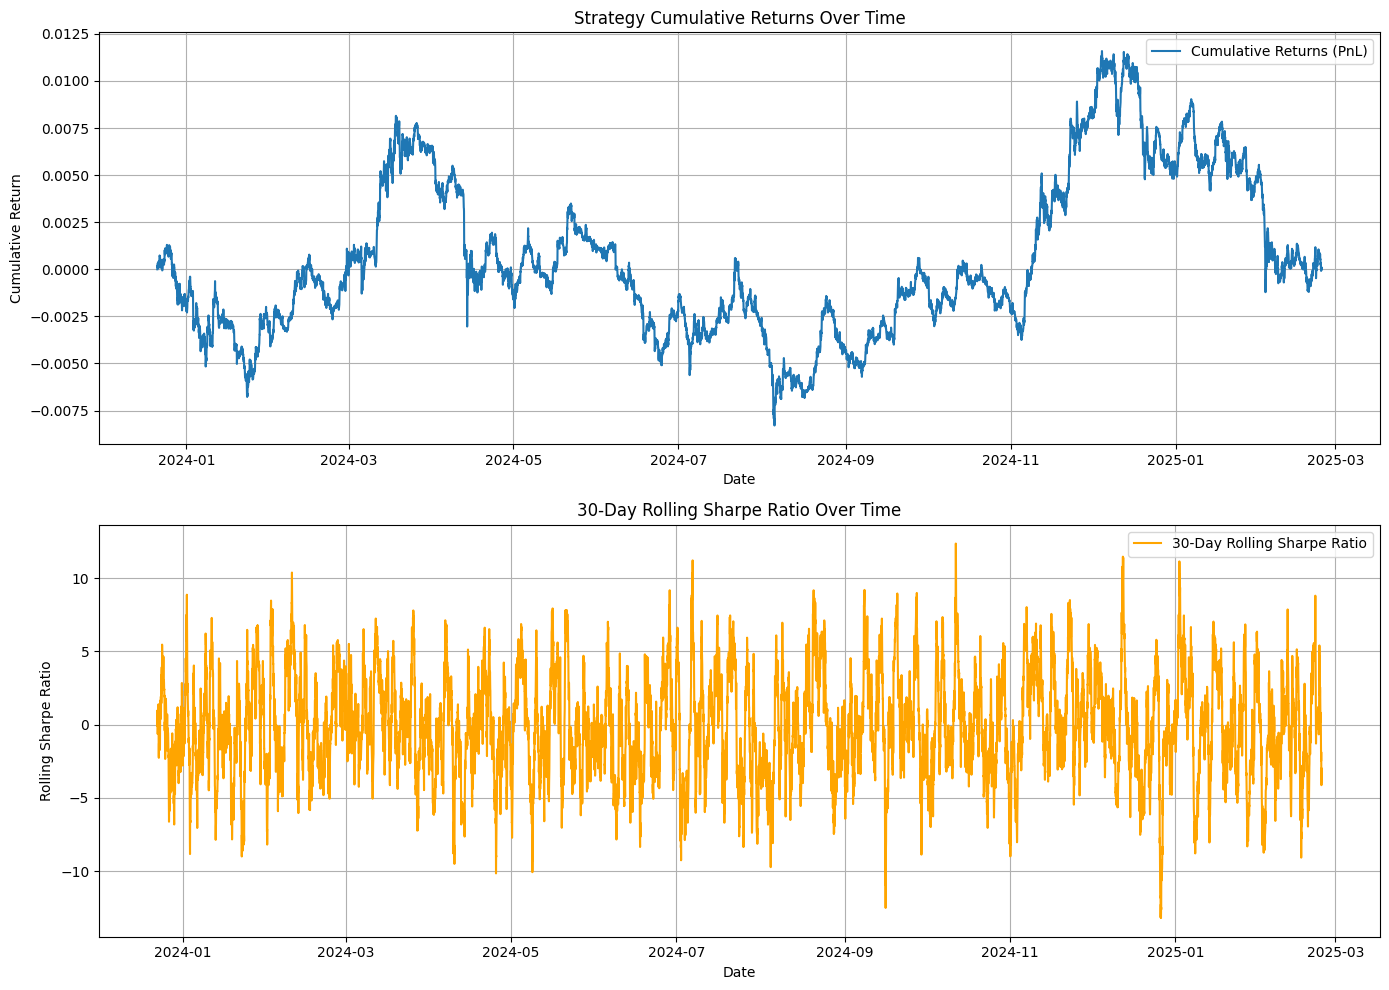

In [54]:
# Define test_data from the combined data split
test_data = data.iloc[split_index:].copy()
test_data['asset_return'] = test_data['price_close'].pct_change()
test_data.dropna(inplace=True)

# Prepare test features and scale them
features_test_aligned = test_data[all_lag_cols].values
X_test_aligned = scaler.transform(features_test_aligned)

# Get prediction probabilities from the trained model
y_pred_test_aligned = best_model.predict(X_test_aligned)

# Define positions as the difference between probability of Buy (assumed index 0)
# and probability of Sell (assumed index 2)
positions_test_aligned = y_pred_test_aligned[:, 0] - y_pred_test_aligned[:, 2]

# Compute the strategy returns: assume positions are applied with a one-period lag
asset_returns_test = test_data['asset_return'].values.astype(np.float32)
strategy_returns_test = np.roll(positions_test_aligned, shift=1) * asset_returns_test
strategy_returns_test[0] = 0  # Set the first return to zero

# Calculate cumulative returns and performance metrics
cumulative_returns_test = np.cumprod(1 + strategy_returns_test) - 1
total_pnl_percentage = cumulative_returns_test[-1]
sharpe_ratio_test = (np.mean(strategy_returns_test) / np.std(strategy_returns_test)) * np.sqrt(365)
initial_capital = 100000
absolute_pnl_test = total_pnl_percentage * initial_capital

print("\nTrading Performance on Test Data:")
print("Total PnL (percentage): {:.2%}".format(total_pnl_percentage))
print("Absolute PnL: ${:,.2f}".format(absolute_pnl_test))
print("Annualized Sharpe Ratio: {:.4f}".format(sharpe_ratio_test))

# Plot performance metrics
dates = test_data.index
cumulative_returns_series = pd.Series(cumulative_returns_test, index=dates)
returns_series = pd.Series(strategy_returns_test, index=dates)

window = 30
rolling_sharpe = returns_series.rolling(window=window).apply(
    lambda r: (np.mean(r) / np.std(r) * np.sqrt(365)) if np.std(r) != 0 else 0,
    raw=True
)

plt.figure(figsize=(14, 10))

plt.subplot(2, 1, 1)
plt.plot(cumulative_returns_series.index, cumulative_returns_series, label='Cumulative Returns (PnL)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Strategy Cumulative Returns Over Time')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(rolling_sharpe.index, rolling_sharpe, label=f'{window}-Day Rolling Sharpe Ratio', color='orange')
plt.xlabel('Date')
plt.ylabel('Rolling Sharpe Ratio')
plt.title(f'{window}-Day Rolling Sharpe Ratio Over Time')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [55]:
#########################################
# Step 9. Run the model 10 more times and show each PnL, abs PnL, and annualized Sharpe
#########################################
num_runs = 10
total_pnl_list = []
absolute_pnl_list = []
sharpe_ratio_list = []

# List to store each newly trained model
model_list = []

for run in range(num_runs):
    print(f"\nTraining run {run+1}/{num_runs}")
    
    # Create a new instance of the same model architecture
    model_run = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(64),
        LeakyReLU(negative_slope=0.1),
        Dense(32),
        LeakyReLU(negative_slope=0.1),
        Dense(y_cat.shape[1], activation='softmax')
    ])
    model_run.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    # Train the model for 50 epochs
    model_run.fit(
        X_train, y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )
    scores_1 = model_run.evaluate(X_test, y_test, verbose=0)
    scores_2 = model_run.evaluate(X_train, y_train, verbose=0)
    print(f"Train accuracy: {scores_2[1]*100:.2f}%")
    print(f"Test accuracy: {scores_1[1]*100:.2f}%")
    # Store this newly trained model in a list
    model_list.append(model_run)
    
    # Evaluate on the test set
    test_data_run = test_data.copy()
    test_data_run['asset_return'] = test_data_run['price_close'].pct_change()
    strategy_data = test_data_run.dropna().copy()
    
    features_test_aligned = strategy_data[all_lag_cols].values
    X_test_aligned = scaler.transform(features_test_aligned)
    
    y_pred_test_aligned = model_run.predict(X_test_aligned)
    
    # Define positions as the difference between probability of Buy (index 0) and Sell (index 2)
    positions_test_aligned = y_pred_test_aligned[:, 0] - y_pred_test_aligned[:, 2]
    
    asset_returns_test = strategy_data['asset_return'].values.astype(np.float32)
    strategy_returns_test = np.roll(positions_test_aligned, shift=1) * asset_returns_test
    strategy_returns_test[0] = 0  # adjust the first value
    
    cumulative_returns_test = np.cumprod(1 + strategy_returns_test) - 1
    total_pnl_percentage = cumulative_returns_test[-1]
    
    # Compute Sharpe ratio; handle zero standard deviation
    std_returns = np.std(strategy_returns_test)
    if std_returns != 0:
        sharpe_ratio_test = (np.mean(strategy_returns_test) / std_returns) * np.sqrt(365)
    else:
        sharpe_ratio_test = 0
        
    initial_capital = 100000
    absolute_pnl_test = total_pnl_percentage * initial_capital
    
    print(f"Run {run+1} Trading Performance:")
    print("  Total PnL (percentage): {:.2%}".format(total_pnl_percentage))
    print("  Absolute PnL: ${:,.2f}".format(absolute_pnl_test))
    print("  Annualized Sharpe Ratio: {:.4f}".format(sharpe_ratio_test))
    
    total_pnl_list.append(total_pnl_percentage)
    absolute_pnl_list.append(absolute_pnl_test)
    sharpe_ratio_list.append(sharpe_ratio_test)

# Compute and display average results over all runs
avg_total_pnl = np.mean(total_pnl_list)
avg_absolute_pnl = np.mean(absolute_pnl_list)
avg_sharpe_ratio = np.mean(sharpe_ratio_list)

print("\nAverage Trading Performance over {} runs:".format(num_runs))
print("  Average Total PnL (percentage): {:.2%}".format(avg_total_pnl))
print("  Average Absolute PnL: ${:,.2f}".format(avg_absolute_pnl))
print("  Average Annualized Sharpe Ratio: {:.4f}".format(avg_sharpe_ratio))

# Now you have 10 separate model instances stored in model_list



Training run 1/10
Test accuracy: 89.97%
317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Run 1 Trading Performance:
  Total PnL (percentage): 21.45%
  Absolute PnL: $21,450.88
  Annualized Sharpe Ratio: 0.3106

Training run 2/10
Test accuracy: 57.25%
317/317 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Run 2 Trading Performance:
  Total PnL (percentage): 30.66%
  Absolute PnL: $30,655.77
  Annualized Sharpe Ratio: 0.4813

Training run 3/10
Test accuracy: 90.19%
317/317 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Run 3 Trading Performance:
  Total PnL (percentage): -1.51%
  Absolute PnL: $-1,514.18
  Annualized Sharpe Ratio: -0.0020

Training run 4/10
Test accuracy: 40.27%
317/317 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Run 4 Trading Performance:
  Total PnL (percentage): -12.10%
  Absolute PnL: $-12,096.68
  Annualized Sharpe Ratio: -0.1636

Training run 5/10
Test accuracy: 90.19%
317/317 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Run 5 Trading Performance:
  Total PnL (percentage): 97.08%
  Absolute PnL: $97,084.12
  Annualized 

In [56]:
"""#########################################
# Step 10. Import separate dataset (Arb)
#########################################
# Import Arb dataset (on-chain and price data)
arb1_features = pd.read_parquet('../data/on_chain_data/processed/arb1_chain_processed.parquet')
arb2_features = pd.read_parquet('../data/on_chain_data/processed/arb2_chain_processed.parquet')
arb_prices = pd.read_parquet('../data/price_data/processed/arb_processed_data.parquet')
arb_tech = pd.read_parquet('../data/data_segmented_tech/arb_data.parquet')

common_columns_arb = arb1_features.columns
arb2_features = arb2_features[common_columns_arb]
arb_features = pd.concat([arb1_features, arb2_features], ignore_index=True)

arb_prices['time_close'] = pd.to_datetime(arb_prices['time_close'])
arb_prices.set_index('time_close', inplace=True)
arb_prices.index = arb_prices.index.tz_localize('UTC')

common_length_2 = min(len(arb_prices), len(arb_features))
arb_prices_aligned = arb_prices.iloc[:common_length_2].copy()
arb_features_aligned = arb_features.iloc[:common_length_2].copy()
arb_features_aligned.index = arb_prices_aligned.index

lag_cols_2 = ['average_gas_limit', 'average_gas_used', 'average_size']
arb_features_aligned[lag_cols_2] = arb_features_aligned[lag_cols_2].shift(1)

data_2 = arb_features_aligned.join(arb_prices_aligned[['price_close']], how='inner')

common_length_tech_2 = min(len(arb_tech), len(arb_prices_aligned))
arb_tech_aligned = arb_tech.iloc[:common_length_tech_2].copy()
arb_tech_aligned.index = arb_prices_aligned.index[:common_length_tech_2]

tech_cols_2 = ['fib_23', 'fib_38', 'fib_50', 'fib_61', 'fib_78', 'bollinger', 'EMAcross', 'RSI']
arb_tech_renamed = arb_tech_aligned[tech_cols_2].rename(columns=lambda x: "tech_" + x)

data_2 = data_2.join(arb_tech_renamed, how='left')
tech_cols_renamed_2 = ["tech_" + col for col in tech_cols_2]
feature_cols_2 = lag_cols_2 + tech_cols_renamed_2"""

'#########################################\n# Step 10. Import separate dataset (Arb)\n#########################################\n# Import Arb dataset (on-chain and price data)\narb1_features = pd.read_parquet(\'../data/on_chain_data/processed/arb1_chain_processed.parquet\')\narb2_features = pd.read_parquet(\'../data/on_chain_data/processed/arb2_chain_processed.parquet\')\narb_prices = pd.read_parquet(\'../data/price_data/processed/arb_processed_data.parquet\')\narb_tech = pd.read_parquet(\'../data/data_segmented_tech/arb_data.parquet\')\n\ncommon_columns_arb = arb1_features.columns\narb2_features = arb2_features[common_columns_arb]\narb_features = pd.concat([arb1_features, arb2_features], ignore_index=True)\n\narb_prices[\'time_close\'] = pd.to_datetime(arb_prices[\'time_close\'])\narb_prices.set_index(\'time_close\', inplace=True)\narb_prices.index = arb_prices.index.tz_localize(\'UTC\')\n\ncommon_length_2 = min(len(arb_prices), len(arb_features))\narb_prices_aligned = arb_prices.iloc

In [57]:
"""#########################################
# Step 11. Use Arb as an out-of-sample test
#########################################
# Generate signals on Arb data
data_2['price_diff'] = data_2['price_close'].diff()
data_2['ewma_diff'] = data_2['price_diff'].ewm(span=6, adjust=False).mean()
threshold_2 = data_2['price_diff'].std()*0.5

def get_signal(diff, threshold):
    if diff > threshold:
        return 'Buy'
    elif diff < -threshold:
        return 'Sell'
    else:
        return 'Hold'

data_2['Signal'] = data_2['ewma_diff'].apply(lambda x: get_signal(x, threshold_2))
data_2 = data_2.dropna()
data_2 = data_2.sort_index()

# Ensure that all feature columns exist in Arb data
missing_features = [col for col in feature_cols if col not in data_2.columns]
if missing_features:
    print("Missing features in Arb data:", missing_features)
    for col in missing_features:
        data_2[col] = 0
data_2 = data_2.reindex(columns=list(set(feature_cols).union(data_2.columns)), fill_value=0)

# Prepare Arb data for evaluation
features_data2 = data_2[feature_cols].values
labels_data2 = data_2['Signal'].values
integer_encoded_data2 = label_encoder.transform(labels_data2)
y_data2 = to_categorical(integer_encoded_data2)
X_data2 = scaler.transform(features_data2)

# Evaluate classification performance on Arb data
loss_data2, accuracy_data2 = best_model.evaluate(X_data2, y_data2, verbose=0)
print("Out-of-Sample Classification Performance:")
print("  Test Loss: {:.4f}".format(loss_data2))
print("  Test Accuracy: {:.4f}".format(accuracy_data2))

# Compute trading performance on Arb data
data_2['asset_return'] = data_2['price_close'].pct_change()
strategy_data2 = data_2.dropna().copy()
features_data2_aligned = strategy_data2[feature_cols].values
X_data2_aligned = scaler.transform(features_data2_aligned)
y_pred_data2 = best_model.predict(X_data2_aligned)
positions_data2 = y_pred_data2[:, 0] - y_pred_data2[:, 2]

asset_returns_data2 = strategy_data2['asset_return'].values.astype(np.float32)
strategy_returns_data2 = np.roll(positions_data2, shift=1) * asset_returns_data2
strategy_returns_data2[0] = 0

cumulative_returns_data2 = np.cumprod(1 + strategy_returns_data2) - 1
total_pnl_percentage_data2 = cumulative_returns_data2[-1]
absolute_pnl_data2 = total_pnl_percentage_data2 * initial_capital
if np.std(strategy_returns_data2) != 0:
    sharpe_ratio_data2 = (np.mean(strategy_returns_data2) / np.std(strategy_returns_data2)) * np.sqrt(365)
else:
    sharpe_ratio_data2 = 0

print("\nOut-of-Sample Trading Performance:")
print("  Total PnL (percentage): {:.2%}".format(total_pnl_percentage_data2))
print("  Absolute PnL: ${:,.2f}".format(absolute_pnl_data2))
print("  Annualized Sharpe Ratio: {:.4f}".format(sharpe_ratio_data2))

# Plot Arb performance metrics
dates = strategy_data2.index
cumulative_returns_series_data2 = pd.Series(cumulative_returns_data2, index=dates)
returns_series_data2 = pd.Series(strategy_returns_data2, index=dates)
window = 5
rolling_sharpe_data2 = returns_series_data2.rolling(window=window).apply(
    lambda r: (np.mean(r) / np.std(r) * np.sqrt(365)) if np.std(r) != 0 else 0,
    raw=True
)

plt.figure(figsize=(14, 10))
plt.subplot(2, 1, 1)
plt.plot(cumulative_returns_series_data2.index, cumulative_returns_series_data2, label='Cumulative Returns (PnL)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Out-of-Sample Strategy Cumulative Returns')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(rolling_sharpe_data2.index, rolling_sharpe_data2, label=f'{window}-Day Rolling Sharpe Ratio', color='orange')
plt.xlabel('Date')
plt.ylabel('Rolling Sharpe Ratio')
plt.title(f'{window}-Day Rolling Sharpe Ratio Over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
"""

'#########################################\n# Step 11. Use Arb as an out-of-sample test\n#########################################\n# Generate signals on Arb data\ndata_2[\'price_diff\'] = data_2[\'price_close\'].diff()\ndata_2[\'ewma_diff\'] = data_2[\'price_diff\'].ewm(span=6, adjust=False).mean()\nthreshold_2 = data_2[\'price_diff\'].std()*0.5\n\ndef get_signal(diff, threshold):\n    if diff > threshold:\n        return \'Buy\'\n    elif diff < -threshold:\n        return \'Sell\'\n    else:\n        return \'Hold\'\n\ndata_2[\'Signal\'] = data_2[\'ewma_diff\'].apply(lambda x: get_signal(x, threshold_2))\ndata_2 = data_2.dropna()\ndata_2 = data_2.sort_index()\n\n# Ensure that all feature columns exist in Arb data\nmissing_features = [col for col in feature_cols if col not in data_2.columns]\nif missing_features:\n    print("Missing features in Arb data:", missing_features)\n    for col in missing_features:\n        data_2[col] = 0\ndata_2 = data_2.reindex(columns=list(set(feature_co